In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier , plot_tree
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression 
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

In [2]:
df = pd.read_csv(r"D:\datasets\seismic-bumps.csv")
df = df.sample(frac = 1).reset_index(drop = True)
df

,seismic,seismoacoustic,shift,genergy,gpuls,gdenergy,gdpuls,hazard,nbumps,nbumps2,nbumps3,nbumps4,nbumps5,nbumps6,nbumps7,nbumps89,energy,maxenergy,class
0,a,a,N,6790,17,-43,-62,a,0,0,0,0,0,0,0,0,0,0,0
1,a,a,W,28140,443,-6,-14,a,0,0,0,0,0,0,0,0,0,0,0
2,b,b,W,42350,1625,70,144,a,0,0,0,0,0,0,0,0,0,0,0
3,a,b,N,155540,363,74,79,a,0,0,0,0,0,0,0,0,0,0,0
4,a,a,N,14020,251,50,-22,a,0,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2579,b,b,W,41230,487,152,70,a,1,1,0,0,0,0,0,0,400,400,0
2580,a,a,N,2910,80,-58,-54,a,0,0,0,0,0,0,0,0,0,0,0
2581,a,a,W,54830,694,46,68,a,5,3,2,0,0,0,0,0,4000,1000,0
2582,a,a,N,3030,29,15,-28,a,0,0,0,0,0,0,0,0,0,0,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2584 entries, 0 to 2583
Data columns (total 19 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   seismic         2584 non-null   object
 1   seismoacoustic  2584 non-null   object
 2   shift           2584 non-null   object
 3   genergy         2584 non-null   int64 
 4   gpuls           2584 non-null   int64 
 5   gdenergy        2584 non-null   int64 
 6   gdpuls          2584 non-null   int64 
 7   hazard          2584 non-null   object
 8   nbumps          2584 non-null   int64 
 9   nbumps2         2584 non-null   int64 
 10  nbumps3         2584 non-null   int64 
 11  nbumps4         2584 non-null   int64 
 12  nbumps5         2584 non-null   int64 
 13  nbumps6         2584 non-null   int64 
 14  nbumps7         2584 non-null   int64 
 15  nbumps89        2584 non-null   int64 
 16  energy          2584 non-null   int64 
 17  maxenergy       2584 non-null   int64 
 18  class   

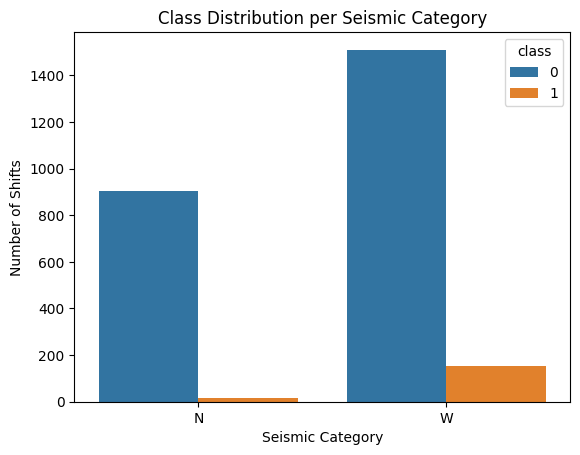

In [4]:
sns.countplot(data=df, x='shift', hue='class')
plt.title('Class Distribution per Seismic Category')
plt.xlabel('Seismic Category')
plt.ylabel('Number of Shifts')
plt.show()

In [5]:
from sklearn.preprocessing import LabelEncoder

In [6]:
for col in ["seismic","seismoacoustic","shift" , "hazard"] :
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])

df.head()

,seismic,seismoacoustic,shift,genergy,gpuls,gdenergy,gdpuls,hazard,nbumps,nbumps2,nbumps3,nbumps4,nbumps5,nbumps6,nbumps7,nbumps89,energy,maxenergy,class
0,0,0,0,6790,17,-43,-62,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,1,28140,443,-6,-14,0,0,0,0,0,0,0,0,0,0,0,0
2,1,1,1,42350,1625,70,144,0,0,0,0,0,0,0,0,0,0,0,0
3,0,1,0,155540,363,74,79,0,0,0,0,0,0,0,0,0,0,0,0
4,0,0,0,14020,251,50,-22,0,0,0,0,0,0,0,0,0,0,0,0


In [7]:
x = df.iloc[: , 0:18]
y = df.iloc[: , -1]
y

0       0
1       0
2       0
3       0
4       0
       ..
2579    0
2580    0
2581    0
2582    0
2583    0
Name: class, Length: 2584, dtype: int64

# Train Test Split

In [8]:
x_train , x_test , y_train , y_test = train_test_split(x , y , test_size=0.3 , random_state=42)
x_train

,seismic,seismoacoustic,shift,genergy,gpuls,gdenergy,gdpuls,hazard,nbumps,nbumps2,nbumps3,nbumps4,nbumps5,nbumps6,nbumps7,nbumps89,energy,maxenergy
331,1,0,1,21660,433,-30,-14,0,0,0,0,0,0,0,0,0,0,0
1075,0,0,0,5470,237,-56,-5,0,0,0,0,0,0,0,0,0,0,0
2469,0,0,1,278230,1060,-31,-18,0,1,1,0,0,0,0,0,0,900,900
1839,0,1,1,15180,196,-3,-21,0,0,0,0,0,0,0,0,0,0,0
444,0,0,1,15820,382,-32,0,0,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1638,0,0,0,59210,175,-54,-61,0,0,0,0,0,0,0,0,0,0,0
1095,1,0,1,134890,1411,-10,9,0,1,0,1,0,0,0,0,0,6000,6000
1130,1,1,1,51910,495,57,73,1,0,0,0,0,0,0,0,0,0,0
1294,0,0,1,29990,203,-55,-75,0,3,1,2,0,0,0,0,0,9400,6000


# Decision Tree classifier 

In [9]:
dt = DecisionTreeClassifier(max_depth=10)
dt.fit(x_train , y_train)


,criterion,'gini'
,splitter,'best'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [10]:
y_pred = dt.predict(x_test)
accuracy_score(y_test , y_pred)

0.913659793814433

[Text(0.5182291666666666, 0.9545454545454546, 'x[8] <= 1.5\ngini = 0.123\nsamples = 1808\nvalue = [1689.0, 119.0]'),
 Text(0.28515625, 0.8636363636363636, 'x[4] <= 1357.0\ngini = 0.071\nsamples = 1459\nvalue = [1405, 54]'),
 Text(0.4016927083333333, 0.9090909090909092, 'True  '),
 Text(0.18802083333333333, 0.7727272727272727, 'x[3] <= 16885.0\ngini = 0.06\nsamples = 1394\nvalue = [1351, 43]'),
 Text(0.14583333333333334, 0.6818181818181818, 'x[16] <= 3500.0\ngini = 0.028\nsamples = 632\nvalue = [623, 9]'),
 Text(0.125, 0.5909090909090909, 'x[4] <= 219.0\ngini = 0.023\nsamples = 607\nvalue = [600, 7]'),
 Text(0.11666666666666667, 0.5, 'x[4] <= 217.0\ngini = 0.037\nsamples = 376\nvalue = [369, 7]'),
 Text(0.08333333333333333, 0.4090909090909091, 'x[6] <= -0.5\ngini = 0.032\nsamples = 374\nvalue = [368.0, 6.0]'),
 Text(0.041666666666666664, 0.3181818181818182, 'x[16] <= 25.0\ngini = 0.018\nsamples = 330\nvalue = [327, 3]'),
 Text(0.025, 0.22727272727272727, 'x[5] <= -84.5\ngini = 0.007\nsa

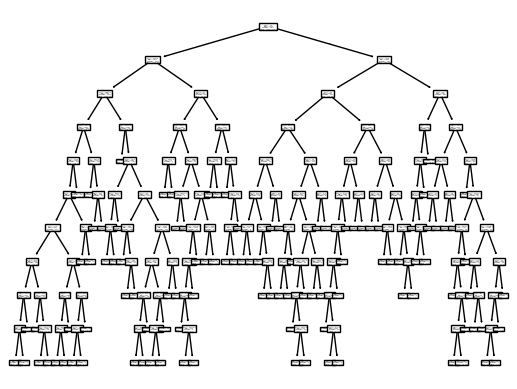

In [11]:
plot_tree(dt)

In [12]:
dt.feature_importances_

array([0.01701121, 0.01499416, 0.00332615, 0.24126611, 0.15424913,
       0.1046471 , 0.12992805, 0.        , 0.10652813, 0.0586301 ,
       0.07322346, 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.0509703 , 0.04522609])

In [13]:
cvs = cross_val_score(dt , x , y , cv=100)
print(cvs.mean() , cvs.std())

0.906923076923077 0.03840087523657387


# Logistic regression 

In [14]:
lr = LogisticRegression()
lr.fit(x_train , y_train)

C:\Users\Anirban Das\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [15]:
y_pred = lr.predict(x_test)
accuracy_score(y_test , y_pred)

0.895618556701031

In [16]:
cvs = cross_val_score(lr , x , y , cv=5)
print(cvs.mean() , cvs.std())

C:\Users\Anirban Das\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\Anirban Das\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    h

0.9020954223081883 0.012473614393576284


C:\Users\Anirban Das\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


# KNN 

In [17]:
knn = KNeighborsClassifier()
knn.fit(x_train , y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [18]:
y_pred = knn.predict(x_test)
accuracy_score(y_test , y_pred)

0.9304123711340206

# Random forest

In [19]:
rc = RandomForestClassifier(max_samples=0.7 , n_estimators=200 , max_depth=10 , random_state=40)

In [20]:
rc.fit(x_train , y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [21]:
y_pred = rc.predict(x_test)
y_pred

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

In [23]:
accuracy_score(y_test , y_pred)

0.9329896907216495